In [1]:
import numpy as np
from scipy.special import erf
from typing import TypedDict

from src.decomposition.tucker import perform_tucker, reconstruct
from src.utils.metrics import relative_error

In [2]:
import numpy as np


def compute_monopole_bc(
    rho: np.ndarray,
    dx: float,
) -> np.ndarray:
    """
    0次多極子展開（モノポール近似）による境界条件の計算。

    グリッド中心を原点とし、全電荷 Q を原点の点電荷とみなして
    各境界格子点のポテンシャルを V = Q / r で与える。

    Parameters
    ----------
    rho : np.ndarray, shape (N, N, N)
        電荷密度
    dx : float
        格子間隔

    Returns
    -------
    V_bc : np.ndarray, shape (N, N, N)
        境界点のみ非ゼロなポテンシャル配列（内部点はすべて 0）
    """
    N = rho.shape[0]

    # ① 全電荷 Q = Σ ρ · dx³
    Q = np.sum(rho) * dx**3

    # ② グリッド座標（中心を原点）
    #    i=0 → -(N-1)/2 * dx,  i=N-1 → +(N-1)/2 * dx
    coords = (np.arange(N) - (N - 1) / 2.0) * dx  # shape (N,)

    # ③ 3D 座標メッシュ（indexing='ij' で x,y,z の軸順を保つ）
    x, y, z = np.meshgrid(coords, coords, coords, indexing="ij")

    # ④ 原点からの距離
    r = np.sqrt(x**2 + y**2 + z**2)

    # ⑤ 原点の特異点を保護（境界点では r>0 なので実際には影響しない）
    r = np.where(r < 1e-10, 1e-10, r)

    # ⑥ モノポールポテンシャル V = Q / r（全点）
    V_mono = Q / r

    # ⑦ 境界マスク：6面を抽出して V_bc に書き込む
    V_bc = np.zeros((N, N, N))
    V_bc[0,  :,  :] = V_mono[0,  :,  :]   # x 方向の負側の面
    V_bc[-1, :,  :] = V_mono[-1, :,  :]   # x 方向の正側の面
    V_bc[:,  0,  :] = V_mono[:,  0,  :]   # y 方向の負側の面
    V_bc[:, -1,  :] = V_mono[:, -1,  :]   # y 方向の正側の面
    V_bc[:,  :,  0] = V_mono[:,  :,  0]   # z 方向の負側の面
    V_bc[:,  :, -1] = V_mono[:,  :, -1]   # z 方向の正側の面

    return V_bc


# ------------------------------------------------------------------ #
# 動作確認：単一ガウシアン電荷分布でテスト
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    N, L = 32, 20.0
    dx = L / N
    alpha = 1.0

    coords = (np.arange(N) - (N - 1) / 2.0) * dx
    x, y, z = np.meshgrid(coords, coords, coords, indexing="ij")
    rho = np.exp(-alpha * (x**2 + y**2 + z**2))

    V_bc = compute_monopole_bc(rho, dx)

    Q = np.sum(rho) * dx**3
    print(f"全電荷 Q     : {Q:.6f}")
    print(f"境界値の最大 : {V_bc.max():.6f}")
    print(f"境界値の最小 : {V_bc[V_bc > 0].min():.6f}")
    print(f"内部点はゼロ : {V_bc[1:-1, 1:-1, 1:-1].max() == 0.0}")

全電荷 Q     : 5.568328
境界値の最大 : 0.574198
境界値の最小 : 0.331858
内部点はゼロ : True


In [3]:
import numpy as np


def laplacian_matvec(V: np.ndarray, dx: float) -> np.ndarray:
    """
    行列フリー 3D (-∇²) の matvec：正定値版。

    CGに渡すために符号を反転させた (-∇²) を実装する。
    各内部点 (i,j,k) で：
        (-∇²V)_{ijk} = (6*V_{ijk} - 隣6点の和) / dx²

    Parameters
    ----------
    V  : shape (N, N, N)  ポテンシャル（境界含む）
    dx : 格子間隔

    Returns
    -------
    AV : shape (N, N, N)  (-∇²V) の結果（内部点のみ非ゼロ）
    """
    AV = np.zeros_like(V)
    inn = slice(1, -1)

    # 中心点 × 6
    AV[inn, inn, inn] = 6.0 * V[inn, inn, inn]

    # 6方向の隣接点を引く
    AV[inn, inn, inn] -= V[0:-2, inn, inn]  # x: i-1
    AV[inn, inn, inn] -= V[2:,   inn, inn]  # x: i+1
    AV[inn, inn, inn] -= V[inn, 0:-2, inn]  # y: j-1
    AV[inn, inn, inn] -= V[inn, 2:,   inn]  # y: j+1
    AV[inn, inn, inn] -= V[inn, inn, 0:-2]  # z: k-1
    AV[inn, inn, inn] -= V[inn, inn, 2:  ]  # z: k+1

    return AV / dx**2


def rhs_with_bc(rho: np.ndarray, V_bc: np.ndarray, dx: float) -> np.ndarray:
    """
    CGに渡す右辺ベクトルを構築する。

    解くべき方程式：(-∇²) V_int = ρ - (-∇²)_bc · V_bc
                                   ^^^  ^^^^^^^^^^^^^^^^^^
                                   本来の右辺   境界値の移項

    Parameters
    ----------
    rho  : shape (N, N, N)  電荷密度
    V_bc : shape (N, N, N)  境界のみ非ゼロ（step1 の出力）
    dx   : 格子間隔

    Returns
    -------
    b : shape (N, N, N)  右辺ベクトル（内部点のみ意味を持つ）
    """
    bc_contribution = laplacian_matvec(V_bc, dx)

    b = np.zeros_like(rho)
    inn = slice(1, -1)
    b[inn, inn, inn] =  4 * np.pi * rho[inn, inn, inn] - bc_contribution[inn, inn, inn]

    return b


# ------------------------------------------------------------------ #
# 動作確認
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    N, dx = 6, 1.0

    # テスト1: 正定値性の確認
    # ランダムな内部ベクトル v に対して v^T A v > 0 になるはず
    np.random.seed(0)
    V = np.zeros((N, N, N))
    V[1:-1, 1:-1, 1:-1] = np.random.randn(N-2, N-2, N-2)
    AV = laplacian_matvec(V, dx)
    inn = slice(1, -1)
    vAv = np.sum(V[inn, inn, inn] * AV[inn, inn, inn])
    print("[テスト1] 正定値性: v^T A v > 0 ?")
    print(f"  v^T A v = {vAv:.6f}  ({'OK' if vAv > 0 else 'NG'})")

    # テスト2: 一様 V=1 の内部点は 0 になるはず（一様場のラプラシアン=0）
    V2 = np.ones((N, N, N))
    V2[0,  :,  :] = 0.0
    V2[-1, :,  :] = 0.0
    V2[:,  0,  :] = 0.0
    V2[:, -1,  :] = 0.0
    V2[:,  :,  0] = 0.0
    V2[:,  :, -1] = 0.0
    AV2 = laplacian_matvec(V2, dx)
    print("\n[テスト2] 純粋内部点(境界に接しない)の (-∇²V) = 0 ?")
    print(f"  AV[2,2,2] = {AV2[2,2,2]:.4f}  (期待値: 0.0)")
    print(f"  AV[1,1,1] = {AV2[1,1,1]:.4f}  (境界隣接: 隣3点=0 → 6-3=3)")

    # テスト3: rhs の符号確認
    rho = np.ones((N, N, N)) * 0.1
    V_bc = np.zeros((N, N, N))
    V_bc[0, :, :] = 1.0
    b = rhs_with_bc(rho, V_bc, dx)
    print("\n[テスト3] rhs_with_bc の確認")
    print(f"  b[1,1,1] = {b[1,1,1]:.4f}  (境界補正あり: rho - bc_contrib)")
    print(f"  b[2,2,2] = {b[2,2,2]:.4f}  (境界から遠い: rho のみ = 0.1)")
    print(f"  b[0,0,0] = {b[0,0,0]:.4f}  (境界点: 0 のまま)")

[テスト1] 正定値性: v^T A v > 0 ?
  v^T A v = 449.920690  (OK)

[テスト2] 純粋内部点(境界に接しない)の (-∇²V) = 0 ?
  AV[2,2,2] = 0.0000  (期待値: 0.0)
  AV[1,1,1] = 3.0000  (境界隣接: 隣3点=0 → 6-3=3)

[テスト3] rhs_with_bc の確認
  b[1,1,1] = 2.2566  (境界補正あり: rho - bc_contrib)
  b[2,2,2] = 1.2566  (境界から遠い: rho のみ = 0.1)
  b[0,0,0] = 0.0000  (境界点: 0 のまま)


In [4]:
def cg_solve(
    matvec,
    b: np.ndarray,
    x0: np.ndarray | None = None,
    tol: float = 1e-6,
    max_iter: int = 1000,
) -> tuple[np.ndarray, list[float]]:
    """
    共役勾配法（Conjugate Gradient）で A x = b を解く。

    A は対称正定値であることが前提。
    A を陽に持たず、matvec(x) = A x を返す関数だけを受け取る。

    Parameters
    ----------
    matvec   : callable  A x を返す関数
    b        : shape (N,N,N)  右辺ベクトル
    x0       : shape (N,N,N)  初期推定解（None なら零ベクトル）
    tol      : 収束判定の相対残差閾値  ||r|| / ||b|| < tol
    max_iter : 最大反復回数

    Returns
    -------
    x        : shape (N,N,N)  近似解
    residuals: list[float]    各反復の相対残差 ||r_k|| / ||b||
    """
    # 初期解
    x = np.zeros_like(b) if x0 is None else x0.copy()

    # 初期残差 r = b - A x
    r = b - matvec(x)

    # 初期探索方向 p = r
    p = r.copy()

    # ||b|| を基準にした相対残差の分母
    b_norm = np.sqrt(np.sum(b * b))
    if b_norm < 1e-14:
        return x, [0.0]

    residuals = []

    for _ in range(max_iter):
        # 相対残差を記録
        r_norm = np.sqrt(np.sum(r * r))
        residuals.append(r_norm / b_norm)

        # 収束判定
        if r_norm / b_norm < tol:
            break

        # A p を計算
        Ap = matvec(p)

        # ステップ幅 α = (r^T r) / (p^T A p)
        rTr = np.sum(r * r)
        pTAp = np.sum(p * Ap)
        alpha = rTr / pTAp

        # 解の更新: x = x + α p
        x = x + alpha * p

        # 残差の更新: r = r - α A p
        r_new = r - alpha * Ap

        # 方向の修正量 β = (r_new^T r_new) / (r^T r)
        beta = np.sum(r_new * r_new) / rTr

        # 探索方向の更新: p = r_new + β p
        p = r_new + beta * p

        r = r_new

    return x, residuals


# ------------------------------------------------------------------ #
# 動作確認：1D の簡単な例で正しさを検証
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    # 1D ポアソン方程式を 3D の特殊ケースとして解く
    # N=8, 解析解が存在する場合で検証

    N = 16
    L = 10.0
    dx = L / N
    alpha = 1.0

    # 電荷密度：単一ガウシアン
    coords = (np.arange(N) - (N - 1) / 2.0) * dx
    x, y, z = np.meshgrid(coords, coords, coords, indexing="ij")
    rho = np.exp(-alpha * (x**2 + y**2 + z**2))

    # 境界条件
    V_bc = compute_monopole_bc(rho, dx)

    # 右辺
    b = rhs_with_bc(rho, V_bc, dx)

    # matvec のラッパー（境界は常に 0 固定）
    def matvec(V: np.ndarray) -> np.ndarray:
        V_with_bc = V.copy()
        return laplacian_matvec(V_with_bc, dx)

    # CG で解く
    V_sol, residuals = cg_solve(matvec, b, tol=1e-8)

    # 境界値を合成して完全な解にする
    V_full = V_sol + V_bc

    print(f"反復回数       : {len(residuals)}")
    print(f"初期残差       : {residuals[0]:.4e}")
    print(f"最終残差       : {residuals[-1]:.4e}")
    print(f"V_full の最大値 : {V_full.max():.6f}")
    print(f"V_full の最小値 : {V_full.min():.6f}")

    # 残差の収束を確認
    print("\n収束履歴（10 反復ごと）")
    for i, res in enumerate(residuals):
        if i % 10 == 0:
            print(f"  iter {i:>4d} : {res:.4e}")

反復回数       : 37
初期残差       : 1.0000e+00
最終残差       : 3.1171e-09
V_full の最大値 : 5.912831
V_full の最小値 : 0.685840

収束履歴（10 反復ごと）
  iter    0 : 1.0000e+00
  iter   10 : 1.0854e-01
  iter   20 : 7.0788e-04
  iter   30 : 8.5027e-07


In [5]:
def poisson_solve(
    rho: np.ndarray,
    dx: float,
    tol: float = 1e-8,
    max_iter: int = 1000,
) -> tuple[np.ndarray, list[float]]:
    """
    ポアソン方程式 (-∇²) V = ρ を解く。

    境界条件: 0次多極子展開（モノポール近似）
    離散化  : 中央差分（2次精度）
    ソルバー: 共役勾配法（CG）

    Parameters
    ----------
    rho      : shape (N, N, N)  電荷密度
    dx       : 格子間隔
    tol      : CGの収束判定閾値（相対残差）
    max_iter : CGの最大反復回数

    Returns
    -------
    V     : shape (N, N, N)  ポテンシャル（境界含む完全な解）
    residuals : list[float]  CGの収束履歴
    """
    # ステップ1: 境界条件（モノポール近似）
    V_bc = compute_monopole_bc(rho, dx)

    # ステップ2: 右辺ベクトルを構築
    b = rhs_with_bc(rho, V_bc, dx)

    # ステップ3: CG で内部点を解く
    def matvec(V: np.ndarray) -> np.ndarray:
        return laplacian_matvec(V, dx)

    V_interior, residuals = cg_solve(matvec, b, tol=tol, max_iter=max_iter)

    # ステップ4: 境界値を足し戻して完全な解を得る
    V = V_interior + V_bc

    return V, residuals


# ------------------------------------------------------------------ #
# 動作確認
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    N = 32
    L = 10.0
    dx = L / N
    alpha = 1.0

    # 電荷密度：単一ガウシアン
    coords = (np.arange(N) - (N - 1) / 2.0) * dx
    x, y, z = np.meshgrid(coords, coords, coords, indexing="ij")
    rho = np.exp(-alpha * (x**2 + y**2 + z**2))

    # ポアソン方程式を解く
    V, residuals = poisson_solve(rho, dx)

    print(f"反復回数       : {len(residuals)}")
    print(f"最終残差       : {residuals[-1]:.4e}")
    print(f"V の最大値     : {V.max():.6f}")
    print(f"V の最小値     : {V.min():.6f}")

    # 精度検証: ∇²V ≈ -rho を数値的に確認
    # 解いた V に再度ラプラシアンを作用させて rho が復元できるか
    AV = laplacian_matvec(V, dx)
    inn = slice(1, -1)
    rho_recovered = AV[inn, inn, inn]
    rho_ref       = rho[inn, inn, inn]
    rel_error = np.linalg.norm(rho_recovered - rho_ref) / np.linalg.norm(rho_ref)
    print(f"\n精度検証 ||AV - rho|| / ||rho|| : {rel_error:.4e}")

反復回数       : 77
最終残差       : 8.6132e-09
V の最大値     : 6.190909
V の最小値     : 0.663716

精度検証 ||AV - rho|| / ||rho|| : 1.1566e+01


In [6]:
from scipy.special import erf


def v_analytic_gaussian(xyz: np.ndarray, alpha: float) -> np.ndarray:
    """
    原点中心の単一ガウシアン電荷の解析ポテンシャルを返す。

    Parameters
    ----------
    xyz   : shape (3, N, N, N)  座標グリッド（xyz[0]=x, xyz[1]=y, xyz[2]=z）
    alpha : ガウシアン幅パラメータ

    Returns
    -------
    V : shape (N, N, N)  解析ポテンシャルグリッド
    """
    R = np.sqrt(xyz[0]**2 + xyz[1]**2 + xyz[2]**2)

    V = np.empty_like(R, dtype=float)
    mask = R > 1e-10

    numerator = (np.pi / alpha) ** 1.5 * erf(np.sqrt(alpha) * R)
    np.divide(numerator, R, out=V, where=mask)

    # 原点の極限値: lim_{R→0} erf(√α R) / R = 2√α / √π
    V[~mask] = 2 * np.pi / alpha

    return V


def build_gaussian_density(xyz: np.ndarray, alpha: float) -> np.ndarray:
    """
    原点中心のガウシアン電荷密度を返す。

    Parameters
    ----------
    xyz   : shape (3, N, N, N)  座標グリッド
    alpha : ガウシアン幅パラメータ

    Returns
    -------
    rho : shape (N, N, N)  電荷密度グリッド
    """
    return np.exp(-alpha * (xyz[0]**2 + xyz[1]**2 + xyz[2]**2))


# ------------------------------------------------------------------ #
# 動作確認
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    N = 32
    L = 10.0
    dx = L / N
    alpha = 1.0

    # 座標グリッドを (3, N, N, N) で構築
    coords = (np.arange(N) - (N - 1) / 2.0) * dx
    x, y, z = np.meshgrid(coords, coords, coords, indexing="ij")
    xyz = np.array([x, y, z])  # shape (3, N, N, N)

    rho = build_gaussian_density(xyz, alpha)
    V_analytic = v_analytic_gaussian(xyz, alpha)

    print(f"xyz.shape       : {xyz.shape}")
    print(f"rho.shape       : {rho.shape}")
    print(f"V_analytic.shape: {V_analytic.shape}")
    print(f"rho の最大値    : {rho.max():.6f}  (期待値: 1.0)")
    print(f"V の最大値      : {V_analytic.max():.6f}  (原点付近)")
    print(f"V の最小値      : {V_analytic.min():.6f}  (境界付近)")

xyz.shape       : (3, 32, 32, 32)
rho.shape       : (32, 32, 32)
V_analytic.shape: (32, 32, 32)
rho の最大値    : 0.929376  (期待値: 1.0)
V の最大値      : 6.133100  (原点付近)
V の最小値      : 0.663716  (境界付近)


In [7]:
from scipy.special import erf


def build_xyz(N: int, L: float) -> np.ndarray:
    """
    座標グリッドを (3, N, N, N) で返す。
 
    N は奇数であること（原点が格子点に乗るため）。
    呼び出し側は N = 2*n+1 の形で渡す。
 
    Parameters
    ----------
    N : 奇数の格子点数
    L : 領域サイズ
 
    Returns
    -------
    xyz : shape (3, N, N, N)
    """
    if N % 2 == 0:
        raise ValueError(f"N は奇数である必要があります（N={N}）。2*n+1 の形で渡してください。")
 
    dx = L / N
    coords = (np.arange(N) - (N - 1) // 2) * dx
    x, y, z = np.meshgrid(coords, coords, coords, indexing="ij")
    return np.array([x, y, z])


def compare(N: int, L: float, alpha: float) -> dict:
    """数値解と解析解を比較して誤差を返す。"""
    dx = L / N
    xyz = build_xyz(N, L)

    rho = build_gaussian_density(xyz, alpha)
    V_numeric, residuals = poisson_solve(rho, dx)
    V_analytic = v_analytic_gaussian(xyz, alpha)

    # 内部点のみで誤差を評価（境界はモノポール近似の誤差が混入するため除外）
    inn = slice(1, -1)
    diff = V_numeric[inn, inn, inn] - V_analytic[inn, inn, inn]
    rel_error = np.linalg.norm(diff) / np.linalg.norm(V_analytic[inn, inn, inn])
    max_error = np.abs(diff).max()

    return {
        "N": N,
        "dx": dx,
        "rel_error": rel_error,
        "max_error": max_error,
        "cg_iter": len(residuals),
        "cg_residual": residuals[-1],
    }


if __name__ == "__main__":
    alpha = 1.0
    L = 10

    print("=" * 60)
    print("  数値解 vs 解析解 比較")
    print("=" * 60)
    print(f"  alpha={alpha}, L={L}")
    print()
    print(f"  {'N':>4} | {'dx':>6} | {'相対誤差':>10} | {'最大誤差':>10} | {'CG反復':>6}")
    print("  " + "-" * 50)

    for N in [17, 33, 65, 129]:
        r = compare(N, L, alpha)
        print(
            f"  {r['N']:>4} | {r['dx']:>6.4f} | "
            f"{r['rel_error']:>10.4e} | {r['max_error']:>10.4e} | "
            f"{r['cg_iter']:>6}"
        )

    print()
    print("  ※ N を2倍にすると相対誤差が約1/4になれば2次精度（中央差分の理論値）")

  数値解 vs 解析解 比較
  alpha=1.0, L=10

     N |     dx |       相対誤差 |       最大誤差 |   CG反復
  --------------------------------------------------
    17 | 0.5882 | 7.6472e-03 | 2.3165e-01 |     40


    33 | 0.3030 | 1.9079e-03 | 5.8502e-02 |     80
    65 | 0.1538 | 4.7995e-04 | 1.4891e-02 |    155
   129 | 0.0775 | 1.2059e-04 | 3.7687e-03 |    291

  ※ N を2倍にすると相対誤差が約1/4になれば2次精度（中央差分の理論値）


In [8]:
def l2_error(V_numeric: np.ndarray, V_analytic: np.ndarray, dx: float) -> float:
    """
    数値解と解析解の L2 ノルム誤差を計算する。
 
    ||V_numeric - V_analytic||_2 / ||V_analytic||_2
 
    内部点のみで評価する（境界はモノポール近似の誤差が混入するため除外）。
 
    Parameters
    ----------
    V_numeric  : shape (N, N, N)  数値解
    V_analytic : shape (N, N, N)  解析解
    dx         : 格子間隔（積分の重みに使用）
 
    Returns
    -------
    rel_error : 相対 L2 誤差
    """
    inn = slice(1, -1)
    diff = V_numeric[inn, inn, inn] - V_analytic[inn, inn, inn]
 
    # L2 ノルム: ||f||_2 = sqrt(∑ f² * dx³)
    numerator   = np.sqrt(np.sum(diff**2) * dx**3)
    denominator = np.sqrt(np.sum(V_analytic[inn, inn, inn]**2) * dx**3)
 
    return numerator / denominator
 
 
if __name__ == "__main__":
    alpha = 1.0
    L = 10.0
 
    print("=" * 55)
    print("  L2 誤差評価：数値解 vs 解析解")
    print("=" * 55)
    print(f"  alpha={alpha}, L={L}")
    print()
    print(f"  {'N':>4} | {'dx':>6} | {'L2 相対誤差':>12} | {'収束次数':>8}")
    print("  " + "-" * 42)
 
    errors = []
    dxs = []
 
    for N in [17, 33, 65]:
        dx = L / N
        xyz = build_xyz(N, L)
        rho = build_gaussian_density(xyz, alpha)
        V_numeric, _ = poisson_solve(rho, dx)
        V_analytic = v_analytic_gaussian(xyz, alpha)
 
        err = l2_error(V_numeric, V_analytic, dx)
        errors.append(err)
        dxs.append(dx)
 
        # 収束次数: log(e_{k-1}/e_k) / log(dx_{k-1}/dx_k)
        if len(errors) >= 2:
            order = np.log(errors[-2] / errors[-1]) / np.log(dxs[-2] / dxs[-1])
            print(f"  {N:>4} | {dx:>6.4f} | {err:>12.4e} | {order:>8.2f}")
        else:
            print(f"  {N:>4} | {dx:>6.4f} | {err:>12.4e} | {'---':>8}")
 
    print()
    print("=" * 55)

  L2 誤差評価：数値解 vs 解析解
  alpha=1.0, L=10.0

     N |     dx |      L2 相対誤差 |     収束次数
  ------------------------------------------
    17 | 0.5882 |   7.6472e-03 |      ---
    33 | 0.3030 |   1.9079e-03 |     2.09
    65 | 0.1538 |   4.7995e-04 |     2.04



In [9]:
from src.decomposition.tucker import perform_tucker, reconstruct


def tucker_poisson_compare(
    rho: np.ndarray,
    xyz: np.ndarray,
    dx: float,
    alpha: float,
    ranks: list[int],
) -> tuple[list[dict], float]:
    """
    Tucker 近似した rho からポテンシャルを求め、解析解と比較する。

    各 rank について：
      1. rho を Tucker 近似 → rho_approx
      2. poisson_solve(rho_approx) → V_approx
      3. l2_error(V_approx, V_analytic) を評価

    Parameters
    ----------
    rho    : shape (N, N, N)  元の電荷密度
    xyz    : shape (3, N, N, N)  座標グリッド
    dx     : 格子間隔
    alpha  : ガウシアン幅パラメータ（解析解の計算に使用）
    ranks  : 評価する rank のリスト

    Returns
    -------
    rows : list[dict]
        rank ごとの誤差・圧縮率の結果
    err_v_ref : float
        フル解像度（rank なし）解の V に対する L2 相対誤差
    """
    N = rho.shape[0]
    V_analytic = v_analytic_gaussian(xyz, alpha)

    # rank なし（フル解像度）の参照解
    V_ref, _ = poisson_solve(rho, dx)
    err_v_ref = l2_error(V_ref, V_analytic, dx)

    rows = []
    for rank in ranks:
        # rho を Tucker 近似
        G, factors = perform_tucker(rho, ranks=[rank, rank, rank])
        rho_approx = reconstruct(G, factors)

        # rho の L2 誤差
        err_rho = l2_error(rho_approx, rho, dx)

        # 近似 rho からポテンシャルを求める
        V_approx, _ = poisson_solve(rho_approx, dx)

        # V の L2 誤差（解析解比較）
        err_v = l2_error(V_approx, V_analytic, dx)

        # 圧縮率：Tucker 表現のパラメータ数 / 元のパラメータ数
        tucker_params = rank**3 + 3 * N * rank
        original_params = N**3
        compression = tucker_params / original_params

        rows.append({
            "rank": rank,
            "err_rho": err_rho,
            "err_v": err_v,
            "compression": compression,
        })

    return rows, err_v_ref


if __name__ == "__main__":
    N = 33
    L = 10.0
    dx = L / N
    alpha = 1.0
    ranks = [1, 2, 4, 8, 12, 16]

    xyz = build_xyz(N, L)
    rho = build_gaussian_density(xyz, alpha)

    rows, err_v_ref = tucker_poisson_compare(rho, xyz, dx, alpha, ranks)

    print("=" * 65)
    print("  Tucker 近似 rho → V の誤差（解析解比較）")
    print("=" * 65)
    print(f"  N={N}, L={L}, alpha={alpha}, dx={dx:.4f}")
    print()
    print(f"  {'rank':>5} | {'rho L2誤差':>12} | {'V L2誤差':>12} | {'圧縮率':>8}")
    print("  " + "-" * 48)
    print(f"  {'ref':>5} | {'---':>12} | {err_v_ref:>12.4e} | {'1.0000':>8}")
    for r in rows:
        print(
            f"  {r['rank']:>5} | {r['err_rho']:>12.4e} | "
            f"{r['err_v']:>12.4e} | {r['compression']:>8.4f}"
        )

    print()
    print("  ※ 圧縮率 < 1 なら Tucker 表現の方がコンパクト")
    print("=" * 65)

  Tucker 近似 rho → V の誤差（解析解比較）
  N=33, L=10.0, alpha=1.0, dx=0.3030

   rank |     rho L2誤差 |       V L2誤差 |      圧縮率
  ------------------------------------------------
    ref |          --- |   1.9079e-03 |   1.0000
      1 |   7.2851e-16 |   1.9079e-03 |   0.0028
      2 |   1.7462e-16 |   1.9079e-03 |   0.0057
      4 |   3.5853e-16 |   1.9079e-03 |   0.0128
      8 |   3.4053e-16 |   1.9079e-03 |   0.0363
     12 |   3.4053e-16 |   1.9079e-03 |   0.0811
     16 |   3.4858e-16 |   1.9079e-03 |   0.1581

  ※ 圧縮率 < 1 なら Tucker 表現の方がコンパクト


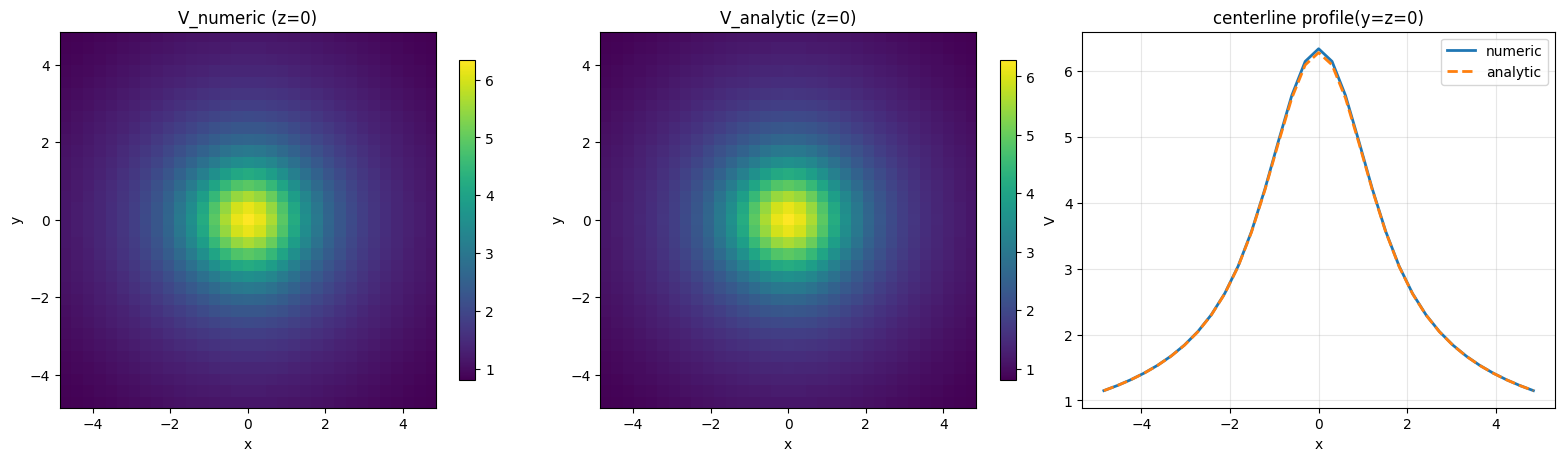

relative L2 error = 1.9079e-03
CG iterations      = 80


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 既存セルで定義済みの関数を使って V を作る（未定義なら既定値で生成）
if "N" not in globals():
    N = 33
if "L" not in globals():
    L = 10.0
if "alpha" not in globals():
    alpha = 1.0

dx = L / N
xyz = build_xyz(N, L)
rho = build_gaussian_density(xyz, alpha)

V_numeric, residuals = poisson_solve(rho, dx)
V_analytic = v_analytic_gaussian(xyz, alpha)

m = N // 2
x = xyz[0, :, m, m]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

# 1) 数値解 V の中央断面
im0 = axes[0].imshow(
    V_numeric[:, :, m],
    origin="lower",
    extent=[x.min(), x.max(), x.min(), x.max()],
    cmap="viridis",
)
axes[0].set_title("V_numeric (z=0)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], shrink=0.85)

# 2) 解析解 V の中央断面
im1 = axes[1].imshow(
    V_analytic[:, :, m],
    origin="lower",
    extent=[x.min(), x.max(), x.min(), x.max()],
    cmap="viridis",
)
axes[1].set_title("V_analytic (z=0)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1], shrink=0.85)

# 3) 中心線プロファイル（x 軸, y=z=0）
axes[2].plot(x, V_numeric[:, m, m], label="numeric", lw=2)
axes[2].plot(x, V_analytic[:, m, m], "--", label="analytic", lw=2)
axes[2].set_title("centerline profile(y=z=0)")
axes[2].set_xlabel("x")
axes[2].set_ylabel("V")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.show()

# 参考: 相対 L2 誤差
print(f"relative L2 error = {l2_error(V_numeric, V_analytic, dx):.4e}")
print(f"CG iterations      = {len(residuals)}")

**rho の誤差が rank=1 で機械精度（1e-15）になる理由：**
 
単一ガウシアンは分離可能テンソルであり、rank=1 で厳密に表現できる。
 
$$\rho(x,y,z) = e^{-\alpha x^2} \cdot e^{-\alpha y^2} \cdot e^{-\alpha z^2}$$
 
x, y, z 方向が完全に独立な積で書けるため、rank を上げても誤差は改善しない。
 
**V の誤差が rank によらず一定な理由：**
 
rho が rank=1 で完全に表現されているため、rank を上げても V は変わらない。
誤差は Tucker 近似の誤差ではなく、**中央差分の離散化誤差そのもの**。

=== single Gaussian rank=3 ===


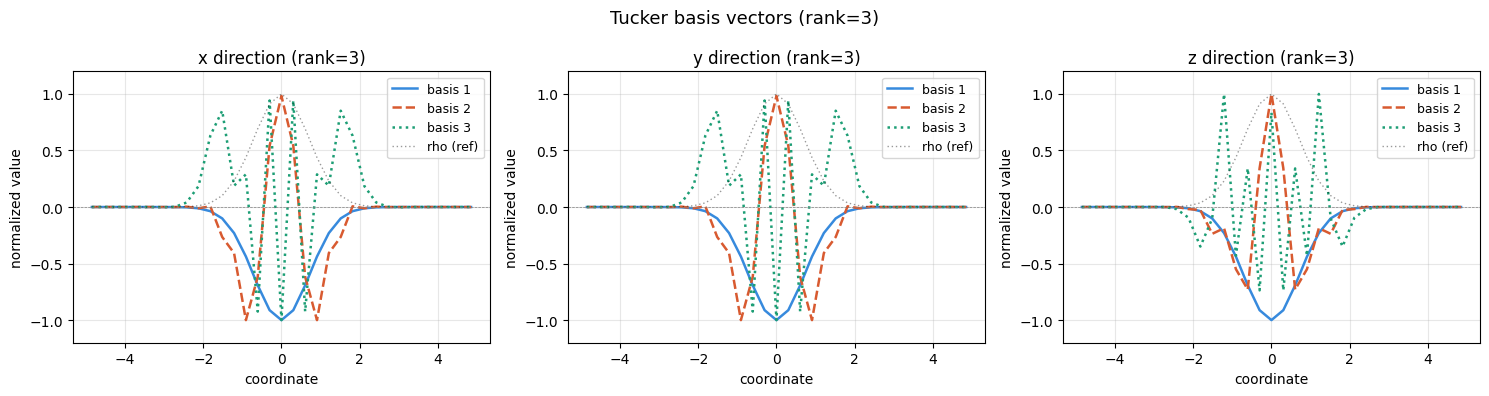

=== multi Gaussian rank=3 ===


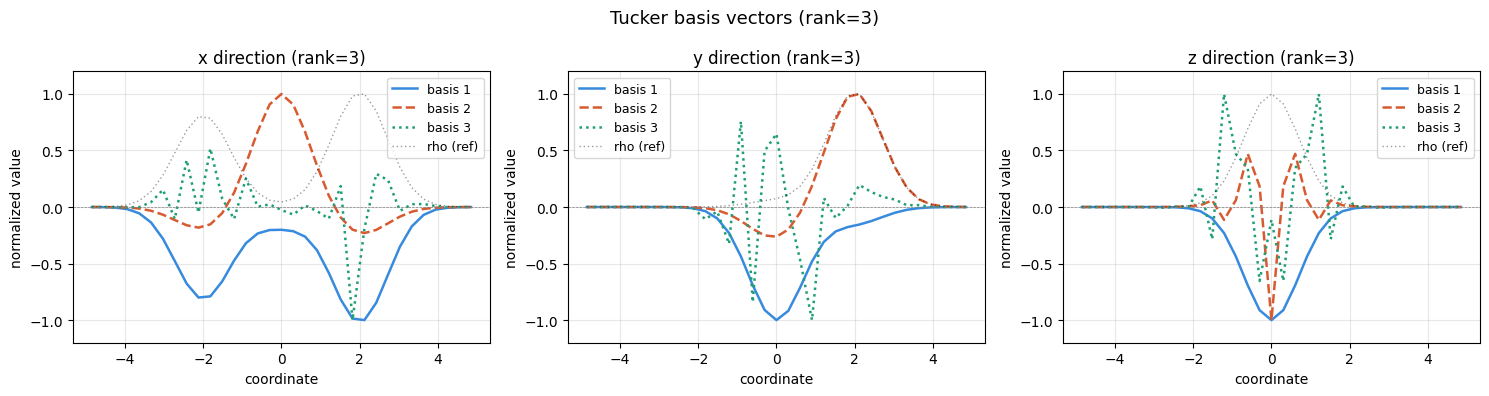

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_basis(
    rho: np.ndarray,
    xyz: np.ndarray,
    rank: int,
    directions: list[str] = ["x", "y", "z"],
    title: str = "",
) -> None:
    """
    Tucker分解の基底ベクトルをプロットする。
 
    各方向（x, y, z）について rank 本の基底ベクトルを表示する。
    基底ベクトルは最大絶対値で正規化して比較しやすくする。
    各方向の rho の中央断面を参考として重ねて表示する。
 
    Parameters
    ----------
    rho        : shape (N, N, N)  電荷密度
    xyz        : shape (3, N, N, N)  座標グリッド
    rank       : Tucker の rank
    directions : プロットする方向のリスト（"x", "y", "z" の部分集合）
    title      : グラフのタイトル（省略時は自動生成）
    """
    G, factors = perform_tucker(rho, ranks=[rank, rank, rank])
 
    N = rho.shape[0]
 
    # 各方向の正しい座標ベクトル
    coord_map = {
        "x": xyz[0, :, 0, 0],
        "y": xyz[1, 0, :, 0],
        "z": xyz[2, 0, 0, :],
    }
 
    # 各方向の rho 中央断面
    m = N // 2
    rho_slice_map = {
        "x": rho[:, m, m],
        "y": rho[m, :, m],
        "z": rho[m, m, :],
    }
 
    factor_map = {"x": factors[0], "y": factors[1], "z": factors[2]}
 
    colors     = ["#378ADD", "#D85A30", "#1D9E75", "#9B59B6", "#E67E22"]
    linestyles = ["-", "--", ":", "-.", (0, (3, 1, 1, 1))]
 
    n_dirs = len(directions)
    fig, axes = plt.subplots(1, n_dirs, figsize=(5 * n_dirs, 4), sharey=False)
    if n_dirs == 1:
        axes = [axes]
 
    for ax, dname in zip(axes, directions):
        coord  = coord_map[dname]
        factor = factor_map[dname]
 
        for p in range(rank):
            vec = factor[:, p]
            vec = vec / (np.abs(vec).max() + 1e-14)
            ax.plot(
                coord, vec,
                color=colors[p % len(colors)],
                linestyle=linestyles[p % len(linestyles)],
                linewidth=1.8,
                label=f"basis {p + 1}",
            )
 
        # rho の断面を参考表示
        sl = rho_slice_map[dname]
        sl = sl / (sl.max() + 1e-14)
        ax.plot(
            coord, sl,
            color="black", linewidth=1.0,
            linestyle=(0, (1, 2)), alpha=0.4,
            label="rho (ref)",
        )
 
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.set_xlabel("coordinate")
        ax.set_ylabel("normalized value")
        ax.set_title(f"{dname} direction (rank={rank})")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_ylim(-1.2, 1.2)
 
    suptitle = title if title else f"Tucker basis vectors (rank={rank})"
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
 
    plt.show()


# ------------------------------------------------------------------ #
# 動作確認
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    import matplotlib
    matplotlib.rcParams["font.family"] = "DejaVu Sans"

    N = 33
    L = 10.0
    alpha = 1.0
    xyz = build_xyz(N, L)

    # 単一ガウシアン
    rho_single = build_gaussian_density(xyz, alpha)

    # 複数ガウシアン
    centers = np.array([[2.0, 0.0, 0.0], [-2.0, 0.0, 0.0], [0.0, 2.0, 0.0]])
    weights = np.array([1.0, 0.8, 0.6])
    rho_multi = sum(
        w * np.exp(-alpha * ((xyz[0] - c[0])**2 + (xyz[1] - c[1])**2 + (xyz[2] - c[2])**2))
        for c, w in zip(centers, weights)
    )

    print("=== single Gaussian rank=3 ===")
    plot_basis(rho_single, xyz, rank=3)

    print("=== multi Gaussian rank=3 ===")
    plot_basis(rho_multi, xyz, rank=3)